In [1]:
import sys
from pathlib import Path

sys.path.insert(0, '../../')
sys.path.insert(0, '../../../jax-power')
import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

plot_dir = Path('validation_imaging_systematics')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

/global/u2/a/adematti/cosmodesi/desi-clustering/clustering_statistics/nb/../../../jax-power/jaxpower/__init__.py


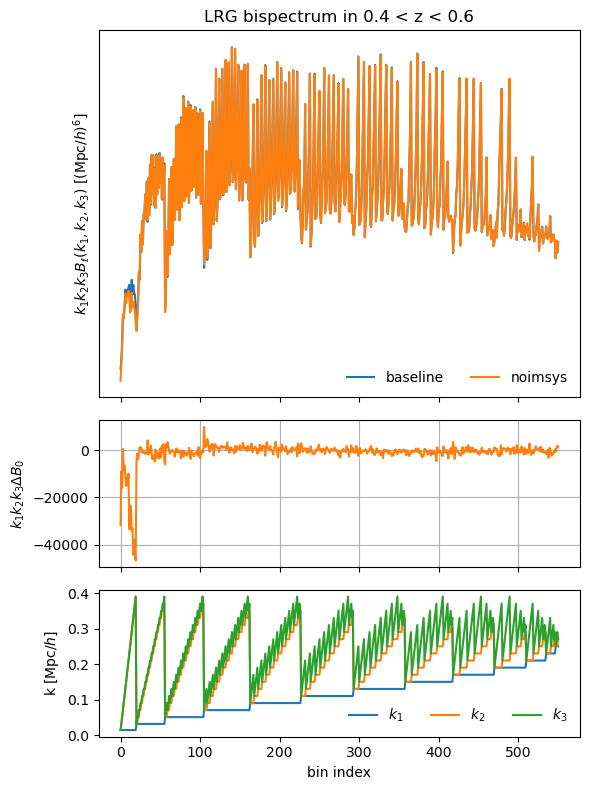

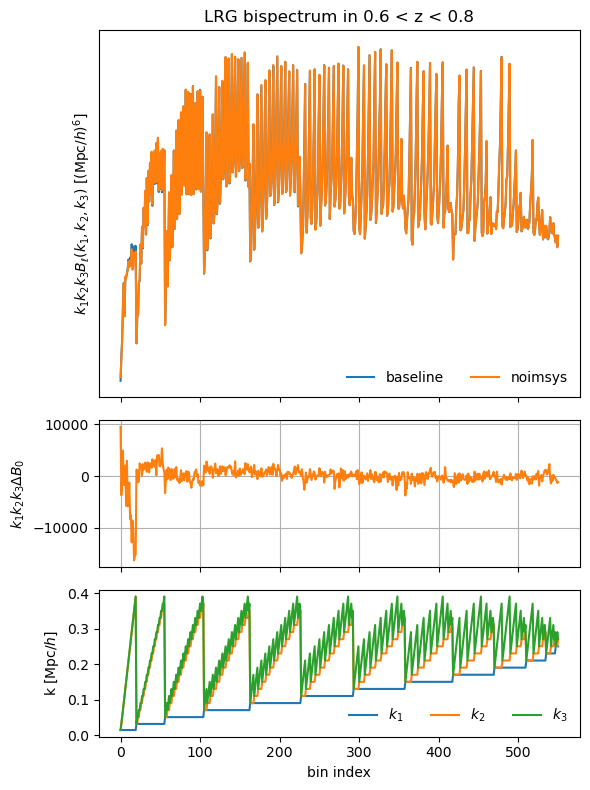

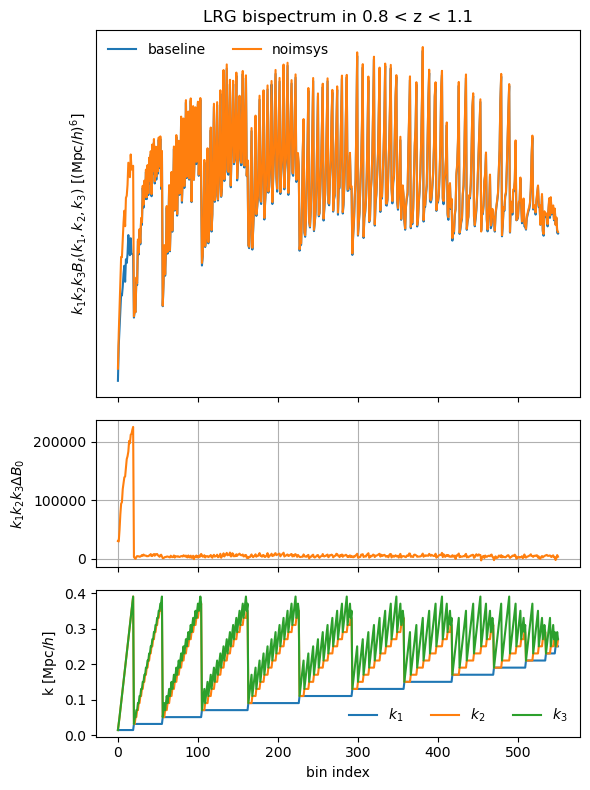

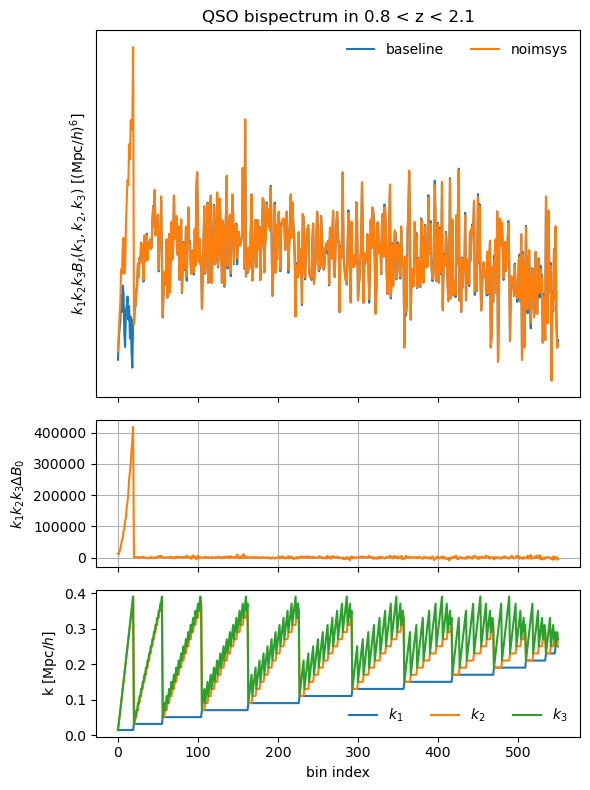

In [9]:
dirname = Path('/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape_protected/imaging_systematics_tests/data-dr2-v2')

for tracer in ['LRG', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        region = 'NGC'
        fn = dirname / f'mesh3_spectrum_scoccimarro_poles_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}_weight-default-FKP.h5'
        fn_noimsys = dirname / f'mesh3_spectrum_scoccimarro_poles_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}_weight-default-FKP-noimsys.h5'
        
        spectra = {'baseline': types.read(fn), 'noimsys': types.read(fn_noimsys)}
        colors = {'baseline': 'C0', 'noimsys': 'C1'}
        version_ref = 'baseline'
        
        ells = spectra['baseline'].ells[:1]
        fig, lax = plt.subplots(2 * len(ells) + 1, figsize=(6, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1] * len(ells) + [1]})
        lax[0].set_title(f'{tracer} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        
        for ill, ell in enumerate(ells):
            ax = lax[ill]
            ax.set_ylabel(r'$k_1 k_2 k_3 B_{\ell}(k_1, k_2, k_3)$ [$(\mathrm{Mpc}/h)^6$]')
            for version, spectrum in spectra.items():
                pole = spectrum.get(ell)
                x = pole.coords('k').prod(axis=-1)
                ax.plot(np.arange(len(x)), x * pole.value().real, color=colors[version], linestyle='-', label=version)
                ax.set_yticks([])
                if ill == 0: ax.legend(frameon=False, ncol=2)
            ax = lax[2 * ill + 1]
            ax.set_ylabel(rf'$k_1 k_2 k_3 \Delta B_{ell:d}$')
            ax.grid(True)
            for version, spectrum in spectra.items():
                if version == version_ref: continue
                pole = spectrum.get(ell)
                x = pole.coords('k').prod(axis=-1)
                ax.plot(np.arange(len(x)), x * (pole.value() - spectra[version_ref].get(ell).value()).real, color=colors[version], linestyle='-')
        ax = lax[-1]
        k = spectrum.get(0).coords('k')
        for idim in range(k.shape[1]):
            ax.plot(np.arange(len(k)), k[..., idim], color=f'C{idim:d}', label=f'$k_{idim + 1:d}$')
        ax.set_ylabel(r'k [$\mathrm{Mpc}/h$]')
        ax.set_xlabel(r'bin index')
        ax.legend(frameon=False, ncol=k.shape[1])
        basename = f'comparison_bispectrum_scoccimarro_weight_sys_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
        plt.tight_layout()
        fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
        plt.show()

### With Gaussian contamination

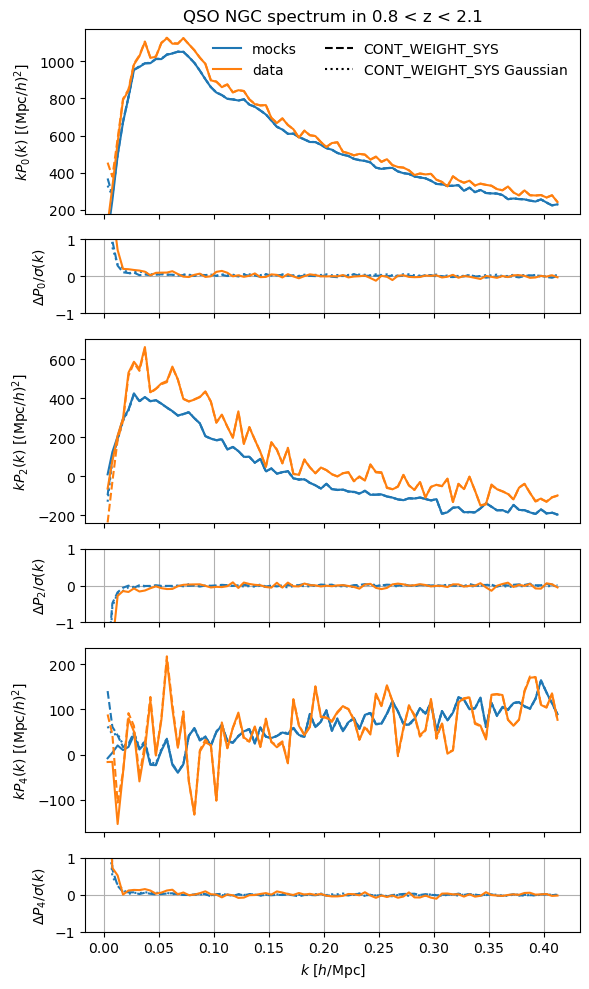

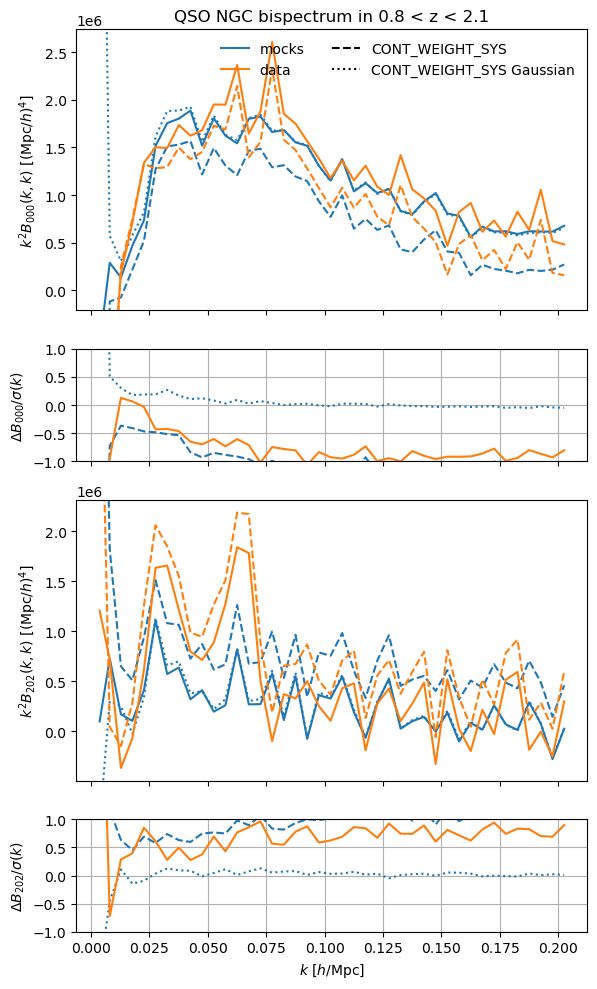

In [5]:
cont_dir = Path('/pscratch/sd/a/adematti/measurements')

tracer = 'QSO'
zrange = (0.8, 2.1)
region = 'NGC'

#tracer = 'LRG'
#zrange = (0.8, 1.1)
#region = 'NGC'

nmocks = 5
version = 'abacus-hf-dr2-v2-altmtl'

for kind in ['mesh2_spectrum', 'mesh3_spectrum']:

    version = 'holi-v3-altmtl'
    if 'BGS' in tracer:
        version = 'holi-bgs-altmtl'
        tracer = 'BGS_BRIGHT-21.35'
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                              zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    cov = types.cov(mocks)
    cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
    #cov = cov.at.observable.select(k=(0., 1.))

    version = 'abacus-hf-dr2-v2-altmtl'
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind, project='full_shape/fiber_assignment_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean = types.mean(mocks).match(cov.observable)

    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-CONT_WEIGHT_SYS', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]
    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean_cont = types.mean(mocks).match(cov.observable)

    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-CONT_WEIGHT_SYS-gaussian', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]
    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean_cont_gaussian = types.mean(mocks).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/fiber_assignment_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                            basis='sugiyama-diagonal')
    data = types.read(fn).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/fiber_assignment_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP-noimsys',
                            basis='sugiyama-diagonal')
    data_noimsys = types.read(fn).match(cov.observable)

    if 'mesh2' in kind:
        ells = mean.ells
        fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
        lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for ill, ell in enumerate(ells):
            ax = lax[2 * ill]
            ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')

            pole = mean.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='-')
            pole = mean_cont.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='--')
            pole = mean_cont_gaussian.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle=':')

            pole = data.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='-')
            pole = data_noimsys.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='--')

            values = []
            for statistic in [mean, mean_cont, mean_cont_gaussian, data, data_noimsys]:
                pole = statistic.get(ell)
                values.append((pole.coords('k') * pole.value())[2:])
            values = np.concatenate(values)
            values = values[np.isfinite(values)]
            if values.size:
                ymin, ymax = np.min(values), np.max(values)
                margin = 0.05 * (ymax - ymin)
                if margin == 0.:
                    margin = 0.05 * max(abs(ymin), 1.)
                ax.set_ylim(ymin - margin, ymax + margin)

            ax = lax[2 * ill + 1]
            ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
            ax.grid(True)
            ax.set_ylim(-1., 1.)

            pole = mean.get(ell)
            pole_cont = mean_cont.get(ell)
            pole_cont_gaussian = mean_cont_gaussian.get(ell)
            std = cov.at.observable.get(ell).std()
            ax.plot(k, (pole_cont.value() - pole.value()) / std, color='C0', linestyle='--')
            ax.plot(k, (pole_cont_gaussian.value() - pole.value()) / std, color='C0', linestyle=':')

            pole = data.get(ell)
            pole_noimsys = data_noimsys.get(ell)
            ax.plot(k, (pole_noimsys.value() - pole.value()) / std, color='C1', linestyle='-')

        ax = lax[0]
        ax.plot([], [], color='C0', linestyle='-', label='mocks')
        ax.plot([], [], color='C1', linestyle='-', label='data')
        ax.plot([], [], color='k', linestyle='--', label='CONT_WEIGHT_SYS')
        ax.plot([], [], color='k', linestyle=':', label='CONT_WEIGHT_SYS Gaussian')
        lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False, ncol=2)

    elif 'mesh3' in kind:
        ells = mean.ells
        fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
        lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for ill, ell in enumerate(ells):
            ax = lax[2 * ill]
            ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')

            pole = mean.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='-')
            pole = mean_cont.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='--')
            pole = mean_cont_gaussian.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle=':')

            pole = data.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='-')
            pole = data_noimsys.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='--')

            values = []
            for statistic in [mean, mean_cont, mean_cont_gaussian, data, data_noimsys]:
                pole = statistic.get(ell)
                ktmp = pole.coords('k')[..., 0]
                values.append((ktmp**2 * pole.value())[2:])
            values = np.concatenate(values)
            values = values[np.isfinite(values)]
            if values.size:
                ymin, ymax = np.min(values), np.max(values)
                margin = 0.05 * (ymax - ymin)
                if margin == 0.:
                    margin = 0.05 * max(abs(ymin), 1.)
                ax.set_ylim(ymin - margin, ymax + margin)

            ax = lax[2 * ill + 1]
            ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
            ax.grid(True)
            ax.set_ylim(-1., 1.)

            pole = mean.get(ell)
            pole_cont = mean_cont.get(ell)
            pole_cont_gaussian = mean_cont_gaussian.get(ell)
            std = cov.at.observable.get(ell).std()
            ax.plot(k, (pole_cont.value() - pole.value()) / std, color='C0', linestyle='--')
            ax.plot(k, (pole_cont_gaussian.value() - pole.value()) / std, color='C0', linestyle=':')

            pole = data.get(ell)
            pole_noimsys = data_noimsys.get(ell)
            ax.plot(k, (pole_noimsys.value() - pole.value()) / std, color='C1', linestyle='-')

        ax = lax[0]
        ax.plot([], [], color='C0', linestyle='-', label='mocks')
        ax.plot([], [], color='C1', linestyle='-', label='data')
        ax.plot([], [], color='k', linestyle='--', label='CONT_WEIGHT_SYS')
        ax.plot([], [], color='k', linestyle=':', label='CONT_WEIGHT_SYS Gaussian')
        lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False, ncol=2)

    basename = f'comparison_cont_weight_sys_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    plt.tight_layout()
    fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

### With LRG contamination

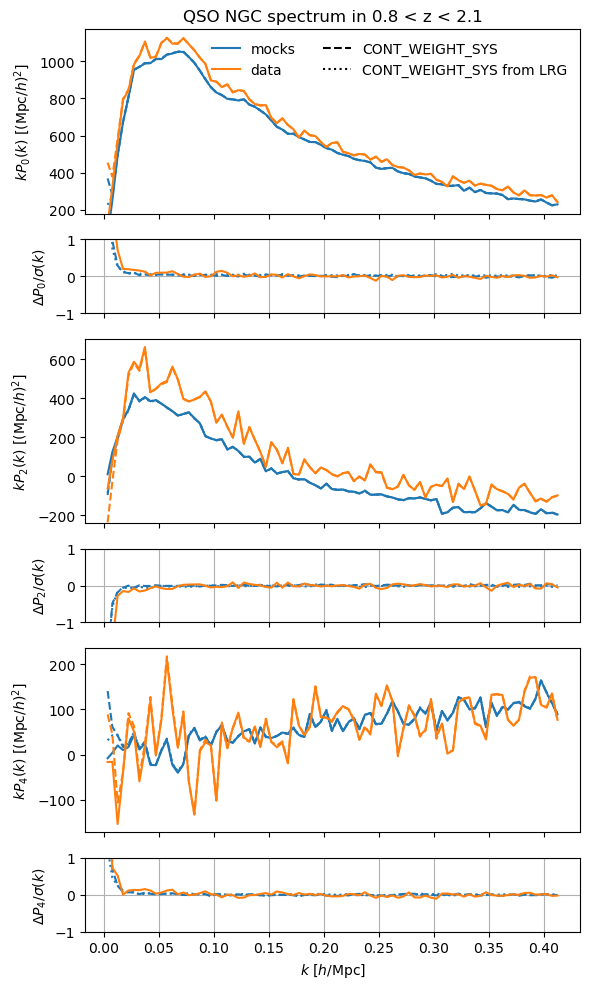

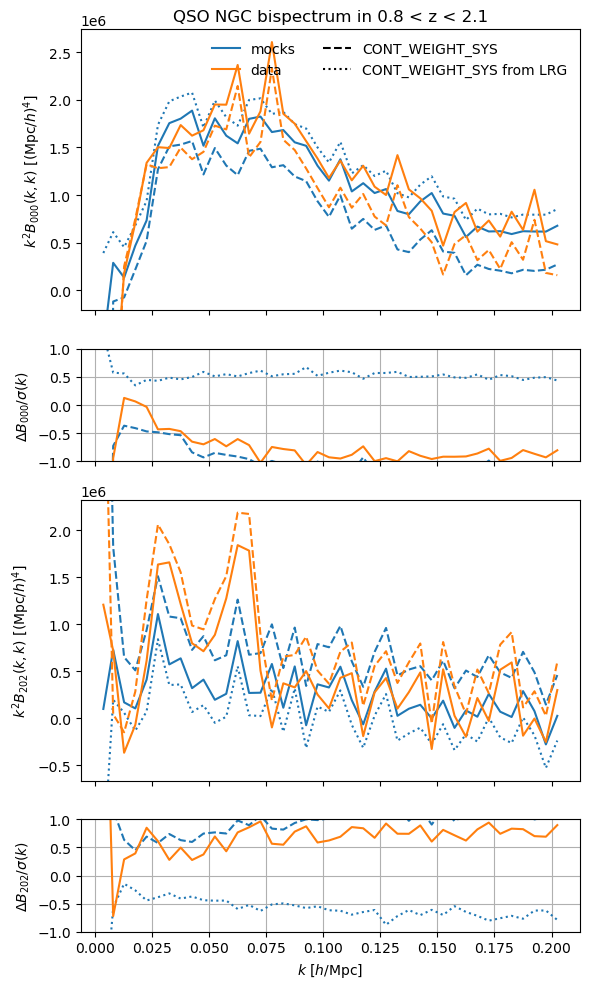

In [10]:
cont_dir = Path('/pscratch/sd/a/adematti/measurements')

tracer = 'QSO'
zrange = (0.8, 2.1)
region = 'NGC'

#tracer = 'LRG'
#zrange = (0.8, 1.1)
#region = 'NGC'

nmocks = 5
version = 'abacus-hf-dr2-v2-altmtl'

for kind in ['mesh2_spectrum', 'mesh3_spectrum']:

    version = 'holi-v3-altmtl'
    if 'BGS' in tracer:
        version = 'holi-bgs-altmtl'
        tracer = 'BGS_BRIGHT-21.35'
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind, project='full_shape/base', version=version, tracer=tracer,
                              zrange=zrange, region=region, weight='default-FKP', basis='sugiyama-diagonal', imock=imock) for imock in range(50)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    cov = types.cov(mocks)
    cov = cov.at.observable.select(k=slice(0, None, 5 if 'mesh2' in kind else 1))
    #cov = cov.at.observable.select(k=(0., 1.))

    version = 'abacus-hf-dr2-v2-altmtl'
    fns = [tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind, project='full_shape/fiber_assignment_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean = types.mean(mocks).match(cov.observable)

    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-CONT_WEIGHT_SYS', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]
    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean_cont = types.mean(mocks).match(cov.observable)

    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-CONT_WEIGHT_SYS-LRG', basis='sugiyama-diagonal',
                              imock=imock) for imock in range(nmocks)]
    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean_cont_gaussian = types.mean(mocks).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/fiber_assignment_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP',
                            basis='sugiyama-diagonal')
    data = types.read(fn).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/fiber_assignment_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP-noimsys',
                            basis='sugiyama-diagonal')
    data_noimsys = types.read(fn).match(cov.observable)

    if 'mesh2' in kind:
        ells = mean.ells
        fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
        lax[0].set_title(f'{tracer} {region} spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for ill, ell in enumerate(ells):
            ax = lax[2 * ill]
            ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')

            pole = mean.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='-')
            pole = mean_cont.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle='--')
            pole = mean_cont_gaussian.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C0', linestyle=':')

            pole = data.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='-')
            pole = data_noimsys.get(ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color='C1', linestyle='--')

            values = []
            for statistic in [mean, mean_cont, mean_cont_gaussian, data, data_noimsys]:
                pole = statistic.get(ell)
                values.append((pole.coords('k') * pole.value())[2:])
            values = np.concatenate(values)
            values = values[np.isfinite(values)]
            if values.size:
                ymin, ymax = np.min(values), np.max(values)
                margin = 0.05 * (ymax - ymin)
                if margin == 0.:
                    margin = 0.05 * max(abs(ymin), 1.)
                ax.set_ylim(ymin - margin, ymax + margin)

            ax = lax[2 * ill + 1]
            ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
            ax.grid(True)
            ax.set_ylim(-1., 1.)

            pole = mean.get(ell)
            pole_cont = mean_cont.get(ell)
            pole_cont_gaussian = mean_cont_gaussian.get(ell)
            std = cov.at.observable.get(ell).std()
            ax.plot(k, (pole_cont.value() - pole.value()) / std, color='C0', linestyle='--')
            ax.plot(k, (pole_cont_gaussian.value() - pole.value()) / std, color='C0', linestyle=':')

            pole = data.get(ell)
            pole_noimsys = data_noimsys.get(ell)
            ax.plot(k, (pole_noimsys.value() - pole.value()) / std, color='C1', linestyle='-')

        ax = lax[0]
        ax.plot([], [], color='C0', linestyle='-', label='mocks')
        ax.plot([], [], color='C1', linestyle='-', label='data')
        ax.plot([], [], color='k', linestyle='--', label='CONT_WEIGHT_SYS')
        ax.plot([], [], color='k', linestyle=':', label='CONT_WEIGHT_SYS from LRG')
        lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False, ncol=2)

    elif 'mesh3' in kind:
        ells = mean.ells
        fig, lax = plt.subplots(len(ells) * 2, figsize=(6, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1] * len(ells)})
        lax[0].set_title(f'{tracer} {region} bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for ill, ell in enumerate(ells):
            ax = lax[2 * ill]
            ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')

            pole = mean.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='-')
            pole = mean_cont.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle='--')
            pole = mean_cont_gaussian.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C0', linestyle=':')

            pole = data.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='-')
            pole = data_noimsys.get(ell)
            ax.plot(k:=pole.coords('k')[..., 0], k**2 * pole.value(), color='C1', linestyle='--')

            values = []
            for statistic in [mean, mean_cont, mean_cont_gaussian, data, data_noimsys]:
                pole = statistic.get(ell)
                ktmp = pole.coords('k')[..., 0]
                values.append((ktmp**2 * pole.value())[2:])
            values = np.concatenate(values)
            values = values[np.isfinite(values)]
            if values.size:
                ymin, ymax = np.min(values), np.max(values)
                margin = 0.05 * (ymax - ymin)
                if margin == 0.:
                    margin = 0.05 * max(abs(ymin), 1.)
                ax.set_ylim(ymin - margin, ymax + margin)

            ax = lax[2 * ill + 1]
            ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
            ax.grid(True)
            ax.set_ylim(-1., 1.)

            pole = mean.get(ell)
            pole_cont = mean_cont.get(ell)
            pole_cont_gaussian = mean_cont_gaussian.get(ell)
            std = cov.at.observable.get(ell).std()
            ax.plot(k, (pole_cont.value() - pole.value()) / std, color='C0', linestyle='--')
            ax.plot(k, (pole_cont_gaussian.value() - pole.value()) / std, color='C0', linestyle=':')

            pole = data.get(ell)
            pole_noimsys = data_noimsys.get(ell)
            ax.plot(k, (pole_noimsys.value() - pole.value()) / std, color='C1', linestyle='-')

        ax = lax[0]
        ax.plot([], [], color='C0', linestyle='-', label='mocks')
        ax.plot([], [], color='C1', linestyle='-', label='data')
        ax.plot([], [], color='k', linestyle='--', label='CONT_WEIGHT_SYS')
        ax.plot([], [], color='k', linestyle=':', label='CONT_WEIGHT_SYS from LRG')
        lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.legend(frameon=False, ncol=2)

    basename = f'comparison_cont_weight_sys_LRG_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    plt.tight_layout()
    fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

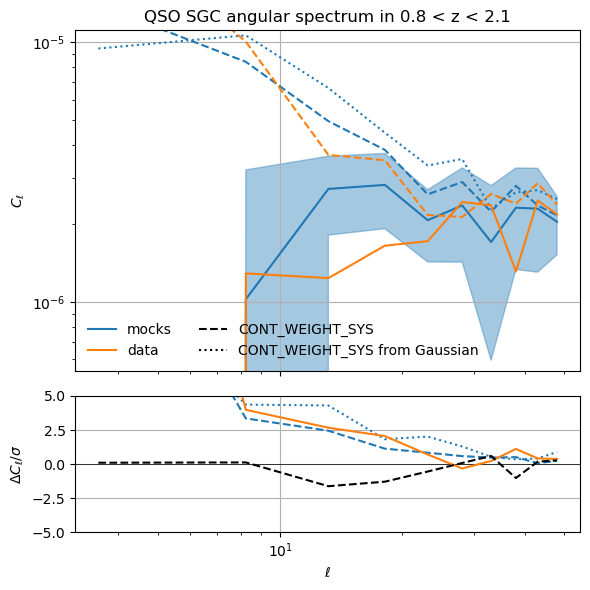

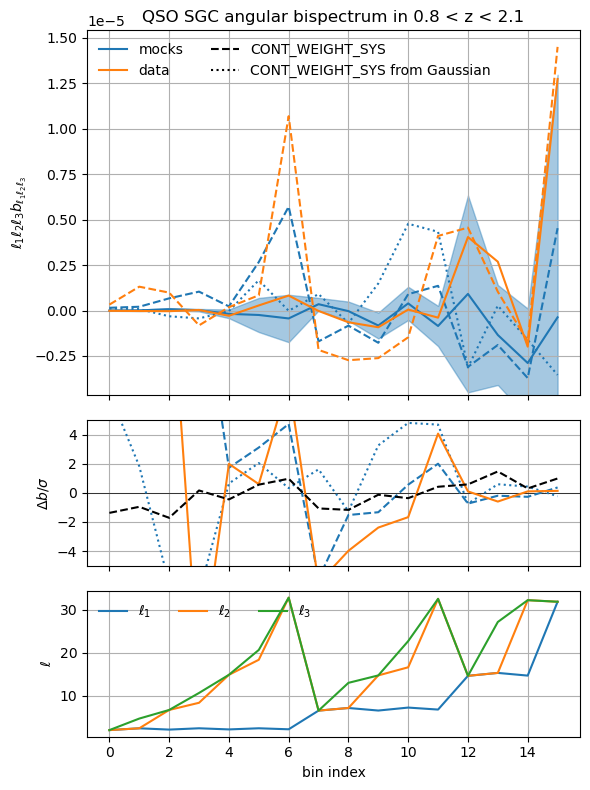

In [37]:
# Same comparison as above, for the angular statistics.
# These are projected on the sky, so they probe the imaging contamination directly.
cont_dir = Path('/pscratch/sd/a/adematti/measurements')

tracer = 'QSO'
zrange = (0.8, 2.1)
region = 'SGC'

#tracer = 'LRG'
#zrange = (0.4, 1.1)
#region = 'NGC'

nmocks = 5

for kind in ['angular2_spectrum', 'angular3_spectrum']:

    version = 'abacus-hf-dr2-v2-altmtl'
    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-SYS_WEIGHT_SYS', imock=imock) for imock in range(nmocks)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    cov = types.cov(mocks)
    if 'angular2' in kind:
        cov = cov.at.observable.select(ell=slice(0, None, 5))
    cov = cov.at.observable.select(ell=(0, 50))
    mean = types.mean(mocks).match(cov.observable)

    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-CONT_WEIGHT_SYS',
                              imock=imock) for imock in range(nmocks)]

    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean_cont = types.mean(mocks).match(cov.observable)

    fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                              version=version, tracer=tracer, zrange=zrange, region=region,
                              weight='default-FKP-wsys-CONT_WEIGHT_SYS-gaussian',
                              imock=imock) for imock in range(nmocks)]
    mocks = [types.read(fn) for fn in fns if fn.exists()]
    mean_cont_gaussian = types.mean(mocks).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/angular_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP')
    data = types.read(fn).match(cov.observable)

    fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                            project='full_shape/angular_systematics', version='data-dr2-v2',
                            tracer=tracer, zrange=zrange, region=region, weight='default-FKP-noimsys')
    data_noimsys = types.read(fn).match(cov.observable)

    std = cov.std()
    statistics = [mean, mean_cont, mean_cont_gaussian, data, data_noimsys]

    npanels = 2 if 'angular2' in kind else 3  # the bispectrum gets the (l1, l2, l3) panel
    fig, lax = plt.subplots(npanels, figsize=(6, 6 if npanels == 2 else 8), sharex=True,
                            gridspec_kw={'height_ratios': [2.5, 1] if npanels == 2 else [2.5, 1, 1]})

    if 'angular2' in kind:
        lax[0].set_title(f'{tracer} {region} angular spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        ell = mean.coords('ell')
        # D_ell = ell (ell + 1) C_ell / (2 pi), the usual flattening of an angular spectrum
        #scale = ell * (ell + 1) / (2. * np.pi)
        scale = 1.
        x = ell
        #lax[0].set_ylabel(r'$\ell(\ell + 1) C_\ell / 2\pi$')
        lax[0].set_ylabel(r'$C_\ell$')
        lax[1].set_ylabel(r'$\Delta C_\ell / \sigma$')
        lax[1].set_xlabel(r'$\ell$')
        lax[0].set_xscale('log')
        lax[0].set_yscale('log')
    else:
        lax[0].set_title(f'{tracer} {region} angular bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        ells = mean.coords('ell')  # (nbins, 3) band centers
        scale = ells.prod(axis=-1)
        x = np.arange(len(ells))
        #lax[0].set_ylabel(r'$b_{\ell_1 \ell_2 \ell_3}$')
        lax[0].set_ylabel(r'$\ell_1 \ell_2 \ell_3 b_{\ell_1 \ell_2 \ell_3}$')
        lax[1].set_ylabel(r'$\Delta b / \sigma$')
        lax[-1].set_xlabel(r'bin index')

    ax = lax[0]
    ax.plot(x, scale * mean.value(), color='C0', linestyle='-')
    ax.fill_between(x, scale * (mean.value() - std), scale * (mean.value() + std), color='C0', alpha=0.4)
    ax.plot(x, scale * mean_cont.value(), color='C0', linestyle='--')
    ax.plot(x, scale * mean_cont_gaussian.value(), color='C0', linestyle=':')
    ax.plot(x, scale * data.value(), color='C1', linestyle='-')
    ax.plot(x, scale * data_noimsys.value(), color='C1', linestyle='--')
    ax.grid(True)

    values = np.concatenate([(scale * statistic.value())[1:] for statistic in statistics])
    values = values[np.isfinite(values)]
    if values.size:
        ymin, ymax = np.min(values), np.max(values)
        margin = 0.05 * (ymax - ymin)
        if margin == 0.:
            margin = 0.05 * max(abs(ymin), 1.)
        ax.set_ylim(ymin - margin, ymax + margin)

    ax = lax[1]
    ax.grid(True)
    ax.axhline(0., color='k', linestyle='-', linewidth=0.5)
    ax.plot(x, (mean_cont.value() - mean.value()) / std, color='C0', linestyle='--')
    ax.plot(x, (mean_cont_gaussian.value() - mean.value()) / std, color='C0', linestyle=':')
    ax.plot(x, (data_noimsys.value() - data.value()) / std, color='C1', linestyle='-')
    ax.plot(x, (data.value() - mean.value()) / std, color='k', linestyle='--')
    # imaging systematics are an angular contamination, so do not clip the residuals to +-1 sigma
    # as for the 3D statistics; scale to the data, with +-1 as a floor
    residuals = np.concatenate([(mean_cont.value() - mean.value()) / std,
                                (mean_cont_gaussian.value() - mean.value()) / std,
                                (data_noimsys.value() - data.value()) / std])
    residuals = residuals[np.isfinite(residuals)]
    ylim = max(1., 1.1 * np.max(np.abs(residuals))) if residuals.size else 1.
    ax.set_ylim(-ylim, ylim)

    if 'angular3' in kind:
        # which (l1, l2, l3) each bin index corresponds to
        ax = lax[-1]
        for idim in range(ells.shape[1]):
            ax.plot(x, ells[..., idim], color=f'C{idim:d}', label=rf'$\ell_{idim + 1:d}$')
        ax.set_ylabel(r'$\ell$')
        ax.legend(frameon=False, ncol=ells.shape[1])
        ax.grid(True)

    lax[1].set_ylim(-5., 5.)
    ax = lax[0]
    ax.plot([], [], color='C0', linestyle='-', label='mocks')
    ax.plot([], [], color='C1', linestyle='-', label='data')
    ax.plot([], [], color='k', linestyle='--', label='CONT_WEIGHT_SYS')
    ax.plot([], [], color='k', linestyle=':', label='CONT_WEIGHT_SYS from Gaussian')
    ax.legend(frameon=False, ncol=2)

    basename = f'comparison_cont_weight_sys_LRG_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    plt.tight_layout()
    fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()


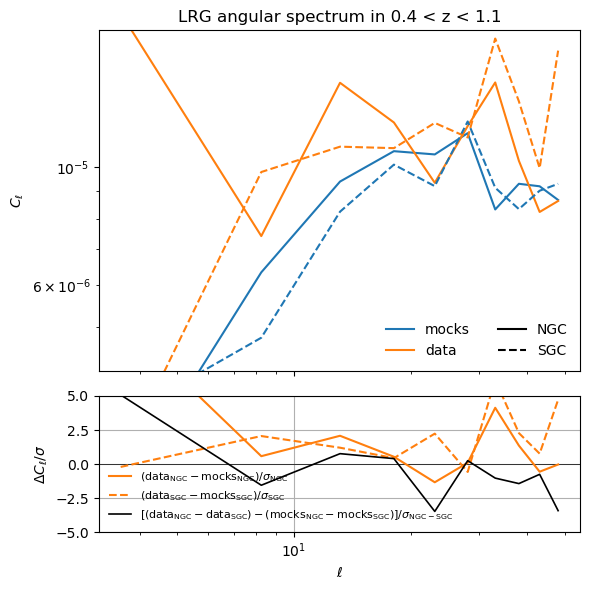

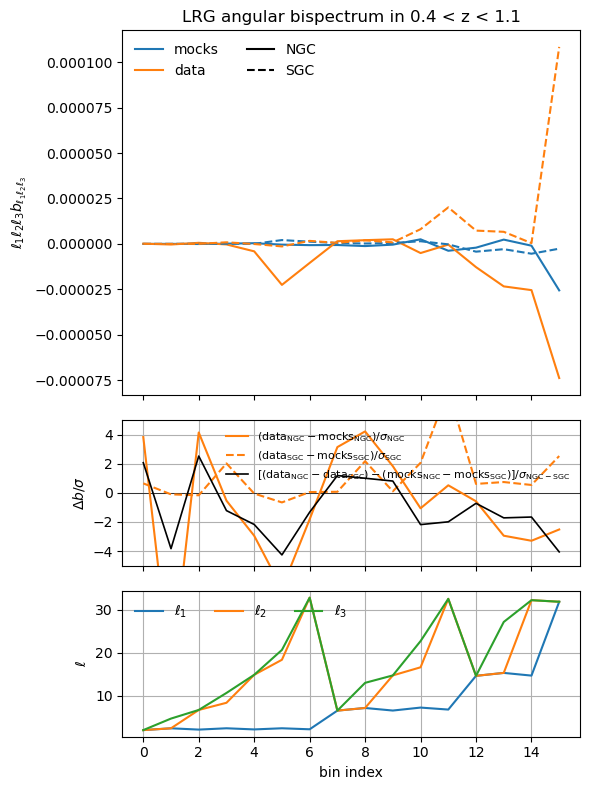

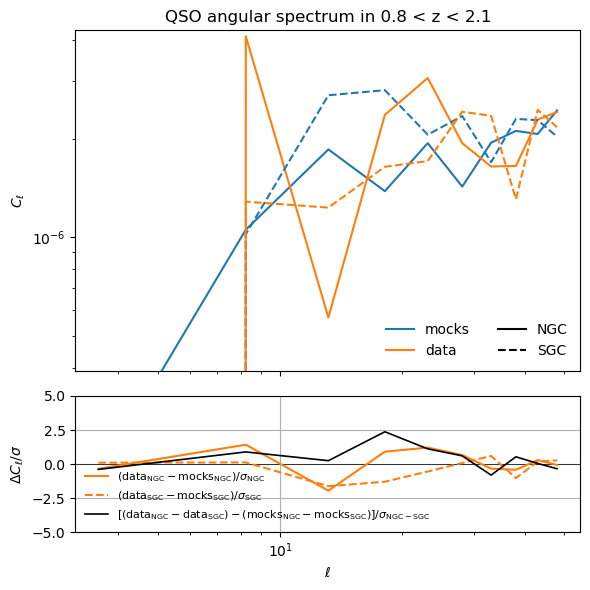

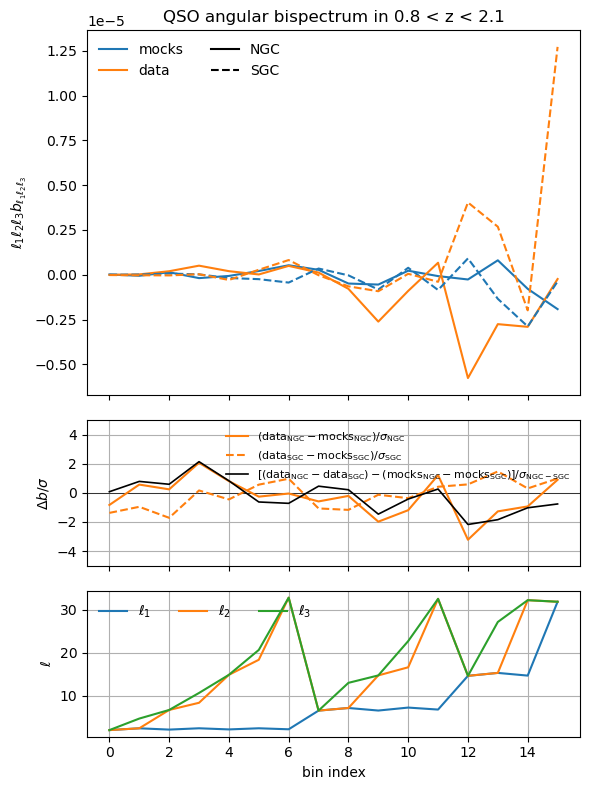

In [40]:
# Compare the LRG angular statistics in NGC and SGC on the same figure.
# The upper panel shows the data and mean mocks; color distinguishes data/mocks,
# while linestyle distinguishes NGC/SGC.
# The lower panel shows:
#   (data_NGC - mocks_NGC) / sigma_NGC
#   (data_SGC - mocks_SGC) / sigma_SGC
#   [(data_NGC - data_SGC) - (mocks_NGC - mocks_SGC)] / sigma_(NGC-SGC)

cont_dir = Path('/pscratch/sd/a/adematti/measurements')

regions = ['NGC', 'SGC']

nmocks = 5

for tracer, zrange in zip(['LRG', 'QSO'], [(0.4, 1.1), (0.8, 2.1)]):
    for kind in ['angular2_spectrum', 'angular3_spectrum']:
    
        version = 'abacus-hf-dr2-v2-altmtl'
    
        mocks, means, covs, stds, data = {}, {}, {}, {}, {}
    
        for region in regions:
    
            fns = [tools.get_stats_fn(stats_dir=cont_dir, kind=kind, project='full_shape/angular_systematics',
                                      version=version, tracer=tracer, zrange=zrange, region=region,
                                      weight='default-FKP-wsys-SYS_WEIGHT_SYS', imock=imock) for imock in range(nmocks)]
    
            mocks[region] = [types.read(fn) for fn in fns if fn.exists()]
            if len(mocks[region]) != nmocks:
                print(f'Found {len(mocks[region]):d}/{nmocks:d} mocks for {tracer} {region} {kind}')
    
            covs[region] = types.cov(mocks[region])
            if 'angular2' in kind:
                covs[region] = covs[region].at.observable.select(ell=slice(0, None, 2))
            covs[region] = covs[region].at.observable.select(ell=(0, 50))
    
            stds[region] = covs[region].std()
            means[region] = types.mean(mocks[region]).match(covs[region].observable)
            mocks[region] = [mock.match(covs[region].observable) for mock in mocks[region]]
    
            fn = tools.get_stats_fn(stats_dir=tools.base_stats_dir, kind=kind,
                                    project='full_shape/angular_systematics', version='data-dr2-v2',
                                    tracer=tracer, zrange=zrange, region=region, weight='default-FKP')
            data[region] = types.read(fn).match(covs[region].observable)
    
        # Use only paired NGC/SGC mocks to estimate the variance of the regional difference.
        npaired = min(len(mocks['NGC']), len(mocks['SGC']))
        mock_differences = [mocks['NGC'][imock].clone(value=mocks['NGC'][imock].value() - mocks['SGC'][imock].value()) for imock in range(npaired)]
        cov_difference = types.cov(mock_differences)
        mean_difference = types.mean(mock_differences)
        std_difference = cov_difference.std()
    
        npanels = 2 if 'angular2' in kind else 3
        fig, lax = plt.subplots(npanels, figsize=(6, 6 if npanels == 2 else 8), sharex=True,
                                gridspec_kw={'height_ratios': [2.5, 1] if npanels == 2 else [2.5, 1, 1]})
    
        if 'angular2' in kind:
            lax[0].set_title(f'{tracer} angular spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            ell = means['NGC'].coords('ell')
            scale = 1.
            x = ell
            lax[0].set_ylabel(r'$C_\ell$')
            lax[1].set_ylabel(r'$\Delta C_\ell / \sigma$')
            lax[1].set_xlabel(r'$\ell$')
            lax[0].set_xscale('log')
            lax[0].set_yscale('log')
        else:
            lax[0].set_title(f'{tracer} angular bispectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
            ells = means['NGC'].coords('ell')
            scale = ells.prod(axis=-1)
            x = np.arange(len(ells))
            lax[0].set_ylabel(r'$\ell_1 \ell_2 \ell_3 b_{\ell_1 \ell_2 \ell_3}$')
            lax[1].set_ylabel(r'$\Delta b / \sigma$')
            lax[-1].set_xlabel(r'bin index')
    
        linestyles = {'NGC': '-', 'SGC': '--'}
    
        ax = lax[0]
        for region in regions:
            ax.plot(x, scale * means[region].value(), color='C0', linestyle=linestyles[region])
            ax.plot(x, scale * data[region].value(), color='C1', linestyle=linestyles[region])
    
        values = np.concatenate([(scale * statistic.value())[1:] for region in regions for statistic in [means[region], data[region]]])
        values = values[np.isfinite(values)]
        if values.size:
            ymin, ymax = np.min(values), np.max(values)
            margin = 0.05 * (ymax - ymin)
            if margin == 0.:
                margin = 0.05 * max(abs(ymin), 1.)
            ax.set_ylim(ymin - margin, ymax + margin)
    
        ax = lax[1]
        ax.grid(True)
        ax.axhline(0., color='k', linestyle='-', linewidth=0.5)
    
        residuals = {}
        for region in regions:
            residuals[region] = (data[region].value() - means[region].value()) / stds[region]
            ax.plot(x, residuals[region], color='C1', linestyle=linestyles[region],
                    label=rf'$(\mathrm{{data}}_{{\rm {region}}} - \mathrm{{mocks}}_{{\rm {region}}}) / \sigma_{{\rm {region}}}$')
    
        residual_difference = ((data['NGC'].value() - data['SGC'].value()) - mean_difference.value()) / std_difference
        ax.plot(x, residual_difference, color='k', linestyle='-', linewidth=1.2,
                label=r'$[(\mathrm{data}_{\rm NGC} - \mathrm{data}_{\rm SGC}) - (\mathrm{mocks}_{\rm NGC} - \mathrm{mocks}_{\rm SGC})] / \sigma_{\rm NGC-SGC}$')
    
        finite_residuals = np.concatenate([residuals['NGC'], residuals['SGC'], residual_difference])
        finite_residuals = finite_residuals[np.isfinite(finite_residuals)]
        ylim = max(1., 1.1 * np.max(np.abs(finite_residuals))) if finite_residuals.size else 1.
        ax.set_ylim(-ylim, ylim)
        ax.legend(frameon=False, fontsize=8)
    
        if 'angular3' in kind:
            ax = lax[-1]
            for idim in range(ells.shape[1]):
                ax.plot(x, ells[..., idim], color=f'C{idim:d}', label=rf'$\ell_{idim + 1:d}$')
            ax.set_ylabel(r'$\ell$')
            ax.legend(frameon=False, ncol=ells.shape[1])
            ax.grid(True)
    
        lax[1].set_ylim(-5., 5.)
    
        ax = lax[0]
        ax.plot([], [], color='C0', linestyle='-', label='mocks')
        ax.plot([], [], color='C1', linestyle='-', label='data')
        ax.plot([], [], color='k', linestyle='-', label='NGC')
        ax.plot([], [], color='k', linestyle='--', label='SGC')
        ax.legend(frameon=False, ncol=2)
    
        basename = f'comparison_data_mocks_{tracer}_{kind}_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_NGC-SGC.{ext}'
        plt.tight_layout()
        fig.savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
        plt.show()